##Implementing simple chatbot using LangGraph

In [12]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END


#reducers
from typing import Annotated
from langgraph.graph.message import add_messages 





In [13]:
class State(TypedDict):
    messages:Annotated[list,add_messages]

In [14]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
os.environ["GOOGLE_API_KEY"] = os.getenv("GOOGLE_API_KEY")

In [16]:
from langchain_groq import ChatGroq

llmgroq = ChatGroq(model="qwen/qwen3-32b")
llmgroq.invoke("tell me something about AI ?")


AIMessage(content='<think>\nOkay, the user asked me to tell them something about AI. Let me start by thinking about what they might need. AI is a broad topic, so I should break it down into key points.\n\nFirst, maybe start with a definition. What is AI? It\'s the simulation of human intelligence by machines, right? But I should be more precise. Mention tasks like learning, reasoning, problem-solving, perception, and language understanding. That covers the main areas.\n\nNext, history. When did AI start? The 1950s with the Dartmouth Conference. Then the early enthusiasm, followed by periods of stagnation called AI winters. Then the resurgence with machine learning and big data. Recent breakthroughs with deep learning and neural networks. That gives a timeline.\n\nKey areas of AI. Machine learning is a big one, where systems learn from data. Then natural language processing for understanding human language. Computer vision for image and video analysis. Robotics for physical tasks. Exper

In [17]:
from langchain_google_genai import ChatGoogleGenerativeAI

llmgoogle = ChatGoogleGenerativeAI(model="gemini-2.5-flash")
llmgoogle.invoke("tell me something about AI ?")

AIMessage(content='Okay, here\'s something fundamental and often misunderstood about AI:\n\n**Most of the AI you interact with today is "Narrow AI" (or "Weak AI"), not "General AI" like in the movies.**\n\nHere\'s what that means:\n\n1.  **Narrow AI:** This type of AI is designed and trained for **one specific task** and excels at it.\n    *   **Examples:**\n        *   The recommendation engine on Netflix or Amazon (recommends products/shows).\n        *   Siri or Alexa (responds to voice commands, sets timers, answers specific questions).\n        *   Spam filters in your email (identifies and filters unwanted messages).\n        *   Facial recognition software (identifies faces).\n        *   AI that plays chess or Go (beats human grandmasters at *that specific game*).\n    *   **Key Characteristic:** It\'s incredibly good at its specific job, but it has no understanding or capability outside of that domain. It can\'t learn a new skill on its own, reason across different contexts, o

Start with creating Nodes

In [18]:
def superbot(state:State):
    return {"messages":[llmgroq.invoke(state["messages"])]}

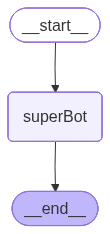

In [22]:
graph =StateGraph(State)

#nodes
graph.add_node("superBot", superbot)


#edges
graph.add_edge(START, "superBot")
graph.add_edge("superBot", END)

graph_builder = graph.compile()

#display

from IPython.display import Image, display
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [28]:
#invocation

graph_builder.invoke({"messages":"Hi my name is Deepak and I like cricket"})

{'messages': [HumanMessage(content='Hi my name is Deepak and I like cricket', additional_kwargs={}, response_metadata={}, id='760651c7-19c9-41bc-8ab5-411b6d409134'),
  AIMessage(content="<think>\nOkay, the user introduced himself as Deepak and mentioned he likes cricket. I need to respond in a friendly and engaging way. Let me start by greeting him and acknowledging his interest in cricket. I can ask how he got into the sport to encourage conversation. I should keep it open-ended so he can share more. Also, maybe mention some aspects of cricket like playing, watching, or following specific teams. Let's make sure the tone is warm and inviting for further interaction. I should avoid any assumptions about his level of expertise or preferences. Keep it simple and positive.\n</think>\n\nHello Deepak! Nice to meet you! 🏏 I'm glad to hear you enjoy cricket—it's such an amazing sport with so much history and excitement. Whether it's the strategy of a tight T20 final, the thrill of a Test match

In [27]:
graph_builder.stream({"messages":"my name is deepak"})

<generator object Pregel.stream at 0x000002543652FB40>